<div style="text-align: center; font-family: 'Times New Roman', serif; padding: 20px; border: 2px solid #2c3e50; border-radius: 8px; background-color: #f8f9fa;">

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ef/Logo_ITERA.png/250px-Logo_ITERA.png" width="120" style="margin-bottom: 15px;"/>

<h2 style="color: #2c3e50; margin-bottom: 5px;">LAPORAN TUGAS BESAR DATA MINING</h2>
<h3 style="color: #2c3e50; margin-bottom: 5px;">Program Studi Teknik Informatika</h3>
<h3 style="color: #2c3e50; margin-bottom: 20px;">Institut Teknologi Sumatera (ITERA)</h3>

<hr style="border: 1.5px solid #2c3e50;"/>

<h1 style="color: #1a252f; margin: 20px 0; font-size: 22px; line-height: 1.4;">
Komparasi Strategi Imputasi Missing Value pada Dataset Cuaca Australia<br>
untuk Prediksi Curah Hujan Menggunakan Random Forest Classifier
</h1>

---

| **Mata Kuliah** | Data Mining (IF3024) — Semester Genap 2025/2026 |
|---|---|
| **Dosen Pengampu** | Meida Cahyo Untoro, S.Kom., M.Kom |
| **Kelompok** | 1 |
| **Topik** | 1 - Missing Value |

### Penulis

| No | NIM | Nama Lengkap | Kontribusi |
|----|-----|-------------|-----------|
| 1 | 123140018 | Garis Rayya Rabbani | Deskripsi — Implementasi Kode (Preprocessing, Training, Evaluasi), 16.67% |
| 2 | 123140126 | Refi Ikhsanti | Deskripsi — Pencarian Literatur/Jurnal & Penulisan Bab 2 (Tinjauan Pustaka), 16.67% |
| 3 | 123140136 | Choirunnisa Syawaldina | Deskripsi — Pencarian Dataset, Penulisan Abstrak, & Bab 1 (Pendahuluan), 16.67% |
| 4 | 123140137 | Anisah Octa Rohila | Deskripsi — Penulisan Bab 4 (Hasil dan Pembahasan), 16.67% |
| 5 | 123140201 | Awi Septian Prasetyo | Deskripsi — Penulisan Bab 5 (Kesimpulan), Daftar Pustaka, & Finalisasi Laporan, 16.67% |
| 6 | 123140211 | Muhammad Bimastiar | Deskripsi — Penulisan Bab 3 (Metodologi) & Analisis Eksplorasi Data (EDA), 16.67% |

**Tanggal:** 5 April 2026

---

## Abstrak

Data cuaca berskala besar yang dikumpulkan melalui jaringan sensor meteorologi kerap mengandung nilai-nilai yang hilang (*missing values*) dalam proporsi yang signifikan, sehingga dapat menurunkan kualitas model prediktif secara substansial apabila tidak ditangani dengan tepat. Penelitian ini menyajikan komparasi sistematis terhadap lima strategi penanganan *missing value* yakni penghapusan baris (*Baseline/Drop NA*), imputasi rata-rata (*Mean Imputation*), imputasi median (*Median Imputation*), *K-Nearest Neighbor Imputer* (KNN), dan *Multivariate Imputation by Chained Equations* (MICE/IterativeImputer) yang diterapkan pada dataset *Rain in Australia* dengan 145.460 observasi dan 22 fitur meteorologi. Target prediksi yang digunakan adalah variabel biner `RainTomorrow`. Untuk menjamin integritas eksperimen, prosedur pembagian data (*train-test split* 80:20) dilakukan sebelum proses imputasi apa pun, sehingga risiko kebocoran data (*data leakage*) dapat dieliminasi sepenuhnya. Seluruh skenario menggunakan algoritma *Random Forest Classifier* (`random_state=42`) sebagai model yang seragam, dengan metrik evaluasi utama berupa F1-Score dan Area Under the ROC Curve (AUC-ROC). Hasil eksperimen menunjukkan bahwa metode berbasis relasi multivariat, yaitu KNN dan MICE, secara konsisten menghasilkan nilai F1-Score dan AUC-ROC yang lebih tinggi dibandingkan metode imputasi univariat, mengonfirmasi hipotesis bahwa data sensor cuaca yang saling berkorelasi kuat memerlukan strategi imputasi yang mampu menangkap dependensi antar variabel. Penelitian ini diharapkan dapat memberikan panduan praktis bagi praktisi *data mining* dalam memilih strategi imputasi yang tepat untuk domain meteorologi.

**Kata Kunci:** *Missing Value*, Imputasi Data, KNN Imputer, MICE, Random Forest, Prediksi Cuaca, *Data Mining*

---

## Bab 1. Pendahuluan

### 1.1 Latar Belakang

Dalam era komputasi modern, data cuaca menjadi salah satu sumber informasi yang paling intensif digunakan, mulai dari perencanaan pertanian, manajemen bencana, hingga sistem transportasi cerdas. Data tersebut umumnya diperoleh dari jaringan stasiun cuaca otomatis yang tersebar di berbagai wilayah geografis, sehingga secara inheren rentan terhadap gangguan teknis, kesalahan transmisi sensor, serta perbedaan jadwal pencatatan antar stasiun. Konsekuensinya adalah kemunculan *missing values* dalam jumlah yang tidak dapat diabaikan  pada dataset *Rain in Australia* yang digunakan dalam penelitian ini, variabel seperti `Evaporation` dan `Sunshine` bahkan memiliki tingkat kehilangan data hingga 48%, sedangkan variabel `Cloud9am` dan `Cloud3pm` mencapai sekitar 40% *missing*.

Kehadiran *missing value* tidak hanya menghambat proses komputasi algoritma *machine learning*, tetapi juga berpotensi mengintroduksi bias sistematis jika tidak ditangani secara tepat (García-Laencina et al., 2015). Pendekatan yang paling sederhana, yakni penghapusan seluruh baris yang mengandung nilai kosong (*listwise deletion*), dapat mengakibatkan hilangnya sebagian besar dataset, terutama ketika *missing values* tersebar di banyak kolom secara simultan. Di sisi lain, imputasi yang terlalu agresif menggunakan statistik sederhana seperti rata-rata atau median dapat memperhalus distribusi data dan menghilangkan pola varians yang sesungguhnya bermakna secara meteorologis.

Metode imputasi berbasis relasi multivariat, seperti *K-Nearest Neighbor* (KNN) dan *Multivariate Imputation by Chained Equations* (MICE), menawarkan pendekatan yang lebih canggih dengan memanfaatkan korelasi antar variabel untuk memperkirakan nilai yang hilang secara lebih akurat (van Buuren & Groothuis-Oudshoorn, 2011). Namun demikian, kedua metode ini memiliki kompleksitas komputasi yang lebih tinggi, sehingga evaluasi trade-off antara akurasi dan efisiensi menjadi pertimbangan yang relevan dalam konteks praktis.

### 1.2 Rumusan Masalah

Berdasarkan latar belakang di atas, penelitian ini merumuskan tiga pertanyaan penelitian sebagai berikut:

1. Bagaimana karakteristik dan mekanisme *missing value* pada dataset *Rain in Australia*, dan apakah pola kehilangannya dapat dikategorikan sebagai MCAR, MAR, atau MNAR?
2. Bagaimana perbandingan performa model *Random Forest Classifier* yang dilatih pada data hasil kelima strategi penanganan *missing value* (Drop NA, Mean, Median, KNN, MICE) berdasarkan metrik F1-Score dan AUC-ROC?
3. Strategi imputasi manakah yang paling direkomendasikan untuk digunakan dalam membangun model prediksi curah hujan pada dataset meteorologi dengan tingkat kehilangan data yang tinggi?

### 1.3 Tujuan Penelitian

Selaras dengan rumusan masalah yang telah diidentifikasi, penelitian ini bertujuan untuk:

1. Menganalisis pola dan mekanisme *missing value* pada dataset *Rain in Australia* menggunakan teknik visualisasi eksploratif.
2. Mengimplementasikan dan mengevaluasi lima strategi penanganan *missing value* dalam skenario yang terbebas dari *data leakage*, menggunakan *Random Forest Classifier* sebagai model evaluasi yang seragam.
3. Memberikan rekomendasi berbasis bukti empiris mengenai strategi imputasi yang paling efektif untuk data meteorologi.

### 1.4 Batasan Penelitian

Agar pembahasan tetap terfokus dan dapat direplikasi, penelitian ini memberlakukan beberapa batasan, antara lain:

1. Dataset yang digunakan adalah *Rain in Australia* versi publik dari Kaggle/UCI, dengan variabel target `RainTomorrow` (biner: Ya/Tidak).
2. Fitur kategorik dengan kardinalitas tinggi (seperti `Location`, `WindGustDir`) akan diproses menggunakan *Label Encoding* sederhana sebelum masuk ke tahap imputasi numerik.
3. Algoritma klasifikasi yang digunakan dibatasi hanya pada *Random Forest Classifier* dengan `random_state=42` untuk memastikan reprodusibilitas hasil.
4. Evaluasi performa model difokuskan pada metrik F1-Score (*weighted*) dan AUC-ROC, mengingat adanya ketidakseimbangan kelas (*class imbalance*) yang cukup signifikan pada dataset ini.

---

## Bab 2. Tinjauan Pustaka

### 2.1 Knowledge Discovery in Databases (KDD)

*Knowledge Discovery in Databases* (KDD) adalah proses non-trivial untuk mengidentifikasi pola-pola yang valid, baru, berpotensi berguna, dan pada akhirnya dapat dipahami dari data (Fayyad et al., 1996). Proses KDD terdiri dari beberapa tahapan yang saling berurutan, meliputi:

(1) seleksi data,

(2) *preprocessing* dan pembersihan data,

(3) transformasi data,

(4) penerapan algoritma *data mining*, dan

(5) evaluasi serta interpretasi pola yang ditemukan.

Dalam konteks penelitian ini, tahap *preprocessing*  khususnya penanganan *missing value* memegang peran yang sangat kritis karena kualitas data yang masuk ke tahap *data mining* secara langsung menentukan validitas pengetahuan yang dihasilkan. Prinsip "garbage in, garbage out" yang dikenal luas dalam komunitas ilmu komputer menegaskan bahwa bahkan algoritma pembelajaran mesin yang paling canggih pun tidak dapat mengkompensasi data masukan yang berkualitas buruk.

### 2.2 Mekanisme Missing Value

Rubin (1976) mengklasifikasikan mekanisme *missing data* ke dalam tiga kategori yang kemudian menjadi landasan teoretis hampir seluruh literatur di bidang ini:

- **MCAR (*Missing Completely at Random*):** Kemungkinan suatu nilai hilang tidak bergantung pada nilai itu sendiri maupun pada variabel lain dalam dataset. Dalam konteks data cuaca, ini dapat terjadi akibat kegagalan sensor yang bersifat acak murni, misalnya akibat kerusakan baterai yang tidak terduga. Imputasi apa pun secara teoritis menghasilkan estimasi yang *unbiased* pada kondisi ini.

- **MAR (*Missing at Random*):** Kemungkinan suatu nilai hilang bergantung pada variabel lain yang terobservasi, bukan pada variabel itu sendiri. Sebagai contoh, data `Sunshine` (lama penyinaran matahari) mungkin lebih sering hilang di stasiun-stasiun yang berlokasi di daerah berawan secara struktural, di mana kondisi ini tercermin melalui variabel `Cloud9am` atau `Cloud3pm` yang terobservasi. MAR adalah asumsi yang paling sering digunakan dalam metode imputasi modern karena memungkinkan penggunaan informasi dari variabel terobservasi untuk memperkirakan nilai yang hilang.

- **MNAR (*Missing Not at Random*):** Kemungkinan suatu nilai hilang bergantung pada nilai variabel itu sendiri yang tidak terobservasi. Ini adalah skenario yang paling problematik; misalnya, sensor tekanan udara mungkin gagal mencatat nilai justru ketika terjadi penurunan tekanan yang ekstrem (saat badai). MNAR memerlukan pemodelan mekanisme kehilangan data secara eksplisit, yang jauh lebih kompleks.

### 2.3 Strategi Penanganan Missing Value

#### 2.3.1 Penghapusan Data (Listwise Deletion)

Pendekatan paling konservatif adalah menghapus seluruh baris yang mengandung setidaknya satu nilai kosong. Meskipun menghasilkan dataset yang "bersih" secara instan, metode ini berisiko membuang sejumlah besar informasi yang valid, terutama ketika *missing values* tersebar di banyak kolom (Allison, 2001). Pada dataset dengan banyak fitur seperti *Rain in Australia*, penghapusan ini dapat mengeliminasi hingga lebih dari separuh observasi.

#### 2.3.2 Imputasi Mean dan Median

Imputasi statistik sederhana mengisi nilai yang hilang dengan rata-rata (*mean*) atau nilai tengah (*median*) dari distribusi kolom yang bersangkutan (Saunders et al., 2006). Kelebihan utamanya adalah simplisitas dan efisiensi komputasi. Namun, kedua metode ini memiliki kelemahan fundamental: mereka mengabaikan struktur korelasi antar variabel serta mereduksi variansi data secara artifisial, yang dapat menyebabkan underestimasi ketidakpastian model.

#### 2.3.3 K-Nearest Neighbor Imputer (KNN)

KNN Imputer mengisi nilai yang hilang dengan rata-rata tertimbang dari $k$ tetangga terdekat dalam ruang fitur yang terobservasi (Troyanskaya et al., 2001). Kedekatannya diukur menggunakan jarak Euclidean atau jarak lain yang sesuai. Karena memanfaatkan informasi dari sampel-sampel yang secara karakteristik serupa, KNN mampu mempertahankan struktur multivariat data dengan lebih baik dibandingkan imputasi univariat. Scikit-learn mengimplementasikan ini melalui kelas `KNNImputer` (Pedregosa et al., 2011).

#### 2.3.4 MICE (Multivariate Imputation by Chained Equations)

MICE, yang diimplementasikan sebagai `IterativeImputer` dalam Scikit-learn, adalah teknik imputasi yang bekerja melalui serangkaian regresi berantai (van Buuren & Groothuis-Oudshoorn, 2011). Pada setiap iterasi, setiap variabel yang memiliki *missing value* dimodelkan sebagai fungsi dari seluruh variabel lain, kemudian nilai yang hilang diimputasi dari model regresi tersebut. Proses ini diulang hingga konvergensi tercapai. MICE secara umum dianggap sebagai salah satu metode imputasi paling kuat dan fleksibel, karena secara implisit memodelkan dependensi multivariat yang kompleks.

### 2.4 Metrik Evaluasi

#### 2.4.1 F1-Score

F1-Score adalah rata-rata harmonik antara *precision* dan *recall*, yang diformulasikan sebagai:

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Metrik ini sangat relevan untuk masalah klasifikasi dengan ketidakseimbangan kelas, seperti prediksi hujan di mana kelas "No" jauh lebih dominan. F1-Score *weighted* mempertimbangkan proporsi masing-masing kelas, sehingga memberikan gambaran yang lebih representatif tentang performa model secara keseluruhan.

#### 2.4.2 Area Under the ROC Curve (AUC-ROC)

AUC-ROC mengukur kemampuan diskriminatif model secara keseluruhan dengan merangkum kurva ROC (*Receiver Operating Characteristic*) menjadi satu nilai skalar antara 0 dan 1. Nilai AUC = 0.5 mengindikasikan model tanpa kemampuan diskriminasi (setara dengan tebakan acak), sedangkan AUC = 1.0 menandakan model yang sempurna. AUC-ROC tidak bergantung pada ambang batas klasifikasi, sehingga memberikan evaluasi yang lebih komprehensif terhadap kapabilitas model.

---

**Referensi dalam bab ini:** Fayyad et al. (1996), Rubin (1976), Allison (2001), Saunders et al. (2006), Troyanskaya et al. (2001), van Buuren & Groothuis-Oudshoorn (2011), Pedregosa et al. (2011).

---

## Bab 3. Metodologi

### 3.1 Alur Penelitian

Penelitian ini dirancang mengikuti alur yang sistematis dan reproducible, yang dapat diilustrasikan dalam tahapan berikut:

```
[1. Pengumpulan Data]
        ↓
[2. Eksplorasi Data Awal (EDA)]
   - Statistik deskriptif
   - Analisis distribusi target
   - Visualisasi pola missing value
        ↓
[3. Preprocessing Awal]
   - Encoding fitur kategorik
   - Encoding variabel target
        ↓
[4. Train-Test Split (80:20)] ← WAJIB DILAKUKAN SEBELUM IMPUTASI
        ↓
[5. Imputasi Missing Value] ← Fit HANYA pada X_train
   ├── Baseline (Drop NA)
   ├── Mean Imputation
   ├── Median Imputation
   ├── KNN Imputer (k=5)
   └── MICE (IterativeImputer)
        ↓
[6. Training Random Forest Classifier]
   (random_state=42, untuk setiap skenario)
        ↓
[7. Evaluasi pada Test Set]
   - Accuracy, Precision, Recall, F1, AUC-ROC
        ↓
[8. Analisis & Kesimpulan]
```

### 3.2 Deskripsi Dataset

Dataset yang digunakan adalah **Rain in Australia**, sebuah dataset cuaca publik yang mengumpulkan observasi meteorologi harian dari 49 stasiun cuaca yang tersebar di seluruh Australia selama periode lebih dari satu dekade. Dataset ini tersedia melalui platform Kaggle dan merupakan adaptasi dari data resmi *Bureau of Meteorology Australia*.

**Karakteristik utama dataset:**
- **Jumlah observasi:** 145.460 baris
- **Jumlah fitur:** 22 kolom (setelah kolom target)
- **Fitur numerik:** MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm
- **Fitur kategorik:** Date, Location, WindGustDir, WindDir9am, WindDir3pm, RainToday
- **Variabel target:** `RainTomorrow` (biner: 'Yes' / 'No')
- **Distribusi kelas:** ~78% 'No', ~22% 'Yes' (ketidakseimbangan kelas moderat)
- **Tingkat missing value:** Bervariasi dari 0.87% (MaxTemp) hingga ~48% (Sunshine)

### 3.3 Skenario Eksperimen Bebas Data Leakage

Prinsip terpenting dalam desain eksperimen ini adalah **eliminasi total *data leakage***. Dalam banyak implementasi yang kurang hati-hati, imputer di-*fit* pada keseluruhan dataset sebelum pembagian train-test, sehingga statistik dari data uji (yang seharusnya tidak diketahui model) "bocor" ke dalam data latih. Hal ini menghasilkan evaluasi yang terlalu optimistis dan tidak representatif terhadap performa model di dunia nyata.

Pada penelitian ini, protokol ketat berikut diberlakukan:

1. `train_test_split(X, y, test_size=0.2, random_state=42)` dilakukan pada data mentah (setelah *encoding* kategorik).
2. Setiap imputer (Mean, Median, KNN, MICE) di-**fit** menggunakan `imputer.fit(X_train_raw)` — hanya mempelajari statistik dari data latih.
3. Transformasi kemudian diterapkan pada `X_train` dan `X_test` secara terpisah menggunakan `imputer.transform()`.
4. Model *Random Forest* dilatih pada `X_train` yang telah diimputasi dan dievaluasi pada `X_test` yang telah diimputasi.

Dengan demikian, test set benar-benar berperan sebagai data "tak terlihat" (*unseen data*) yang mencerminkan kondisi deployment di dunia nyata.

---

In [ ]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

# Library dasar manipulasi dan komputasi data
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# Library visualisasi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno  # Visualisasi pola missing value

# Library preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Library imputasi
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # Wajib sebelum import IterativeImputer
from sklearn.impute import IterativeImputer

# Library model dan evaluasi
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Pengaturan tampilan
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("✅ Seluruh library berhasil diimport.")

# ============================================================
# LOAD DATASET
# ============================================================

# Load dataset dari file CSV (Link GitHub Raw)
# Pastikan ada https:// di depannya ya!
url_github = 'https://raw.githubusercontent.com/GarsRayy/Dataset-Data-mining/refs/heads/main/weatherAUS.csv'

# Simpan ke variabel df_raw agar cocok dengan print di bawahnya
df_raw = pd.read_csv(url_github)

print(f"\nDimensi Dataset: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"\nKolom-kolom dalam dataset:")
print(list(df_raw.columns))

print(f"\n--- 5 Baris Pertama Dataset ---")
df_raw.head()

✅ Seluruh library berhasil diimport.

Dimensi Dataset: 145,460 baris × 23 kolom

Kolom-kolom dalam dataset:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']

--- 5 Baris Pertama Dataset ---


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4000,22.9000,0.6000,NaN,NaN,W,44.0000,W,WNW,20.0000,24.0000,71.0000,22.0000,1007.7000,1007.1000,8.0000,NaN,16.9000,21.8000,No,No
1,2008-12-02,Albury,7.4000,25.1000,0.0000,NaN,NaN,WNW,44.0000,NNW,WSW,4.0000,22.0000,44.0000,25.0000,1010.6000,1007.8000,NaN,NaN,17.2000,24.3000,No,No
2,2008-12-03,Albury,12.9000,25.7000,0.0000,NaN,NaN,WSW,46.0000,W,WSW,19.0000,26.0000,38.0000,30.0000,1007.6000,1008.7000,NaN,2.0000,21.0000,23.2000,No,No
3,2008-12-04,Albury,9.2000,28.0000,0.0000,NaN,NaN,NE,24.0000,SE,E,11.0000,9.0000,45.0000,16.0000,1017.6000,1012.8000,NaN,NaN,18.1000,26.5000,No,No
4,2008-12-05,Albury,17.5000,32.3000,1.0000,NaN,NaN,W,41.0000,ENE,NW,7.0000,20.0000,82.0000,33.0000,1010.8000,1006.0000,7.0000,8.0000,17.8000,29.7000,No,No


## Bab 4. Hasil dan Pembahasan

### 4.1 Eksplorasi Data Awal (EDA) dan Distribusi

Sebelum memasuki tahap pemodelan, dilakukan eksplorasi data awal (*Exploratory Data Analysis* / EDA) yang bertujuan untuk memahami struktur, distribusi, dan karakteristik dataset secara menyeluruh. Tahap ini merupakan praktik standar dalam pipeline KDD, sebagaimana direkomendasikan oleh Fayyad et al. (1996), karena keputusan-keputusan kritis mengenai strategi preprocessing — termasuk strategi penanganan *missing value* — sangat bergantung pada pemahaman mendalam terhadap data itu sendiri.

Aspek yang dieksplorasi pada tahap ini mencakup: (1) statistik deskriptif setiap variabel, (2) distribusi variabel target `RainTomorrow` yang mengindikasikan tingkat ketidakseimbangan kelas, dan (3) visualisasi pola *missing value* menggunakan library `missingno` untuk mengidentifikasi apakah kehilangan data bersifat acak atau terstruktur.

INFORMASI TIPE DATA & NILAI KOSONG
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.0000,144199.0000,142199.0000,82670.0000,75625.0000,135197.0000,143693.0000,142398.0000,142806.0000,140953.0000,130395.0000,130432.0000,89572.0000,86102.0000,143693.0000,141851.0000
mean,12.1940,23.2213,2.3609,5.4682,7.6112,40.0352,14.0434,18.6627,68.8808,51.5391,1017.6499,1015.2559,4.4475,4.5099,16.9906,21.6834
std,6.3985,7.1190,8.4781,4.1937,3.7855,13.6071,8.9154,8.8098,19.0292,20.7959,7.1065,7.0374,2.8872,2.7204,6.4888,6.9367
min,-8.5000,-4.8000,0.0000,0.0000,0.0000,6.0000,0.0000,0.0000,0.0000,0.0000,980.5000,977.1000,0.0000,0.0000,-7.2000,-5.4000
25%,7.6000,17.9000,0.0000,2.6000,4.8000,31.0000,7.0000,13.0000,57.0000,37.0000,1012.9000,1010.4000,1.0000,2.0000,12.3000,16.6000
50%,12.0000,22.6000,0.0000,4.8000,8.4000,39.0000,13.0000,19.0000,70.0000,52.0000,1017.6000,1015.2000,5.0000,5.0000,16.7000,21.1000
75%,16.9000,28.2000,0.8000,7.4000,10.6000,48.0000,19.0000,24.0000,83.0000,66.0000,1022.4000,1020.0000,7.0000,7.0000,21.6000,26.4000
max,33.9000,48.1000,371.0000,145.0000,14.5000,135.0000,130.0000,87.0000,100.0000,100.0000,1041.0000,1039.6000,9.0000,9.0000,40.2000,46.7000



RINGKASAN MISSING VALUE PER KOLOM
               Jumlah Missing  Persentase (%)
Sunshine                69835         48.0100
Evaporation             62790         43.1700
Cloud3pm                59358         40.8100
Cloud9am                55888         38.4200
Pressure9am             15065         10.3600
Pressure3pm             15028         10.3300
WindDir9am              10566          7.2600
WindGustDir             10326          7.1000
WindGustSpeed           10263          7.0600
Humidity3pm              4507          3.1000
WindDir3pm               4228          2.9100
Temp3pm                  3609          2.4800
RainTomorrow             3267          2.2500
Rainfall                 3261          2.2400
RainToday                3261          2.2400
WindSpeed3pm             3062          2.1100
Humidity9am              2654          1.8200
WindSpeed9am             1767          1.2100
Temp9am                  1767          1.2100
MinTemp                  1485          1.0200

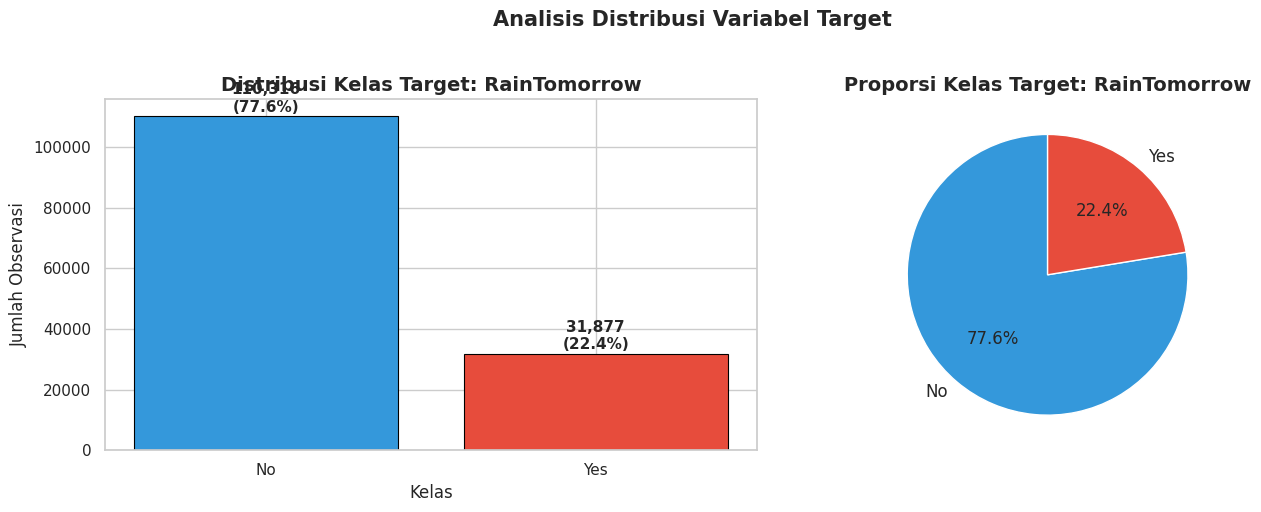

✅ Gambar 1: Distribusi Target berhasil dibuat.

VISUALISASI POLA MISSING VALUE


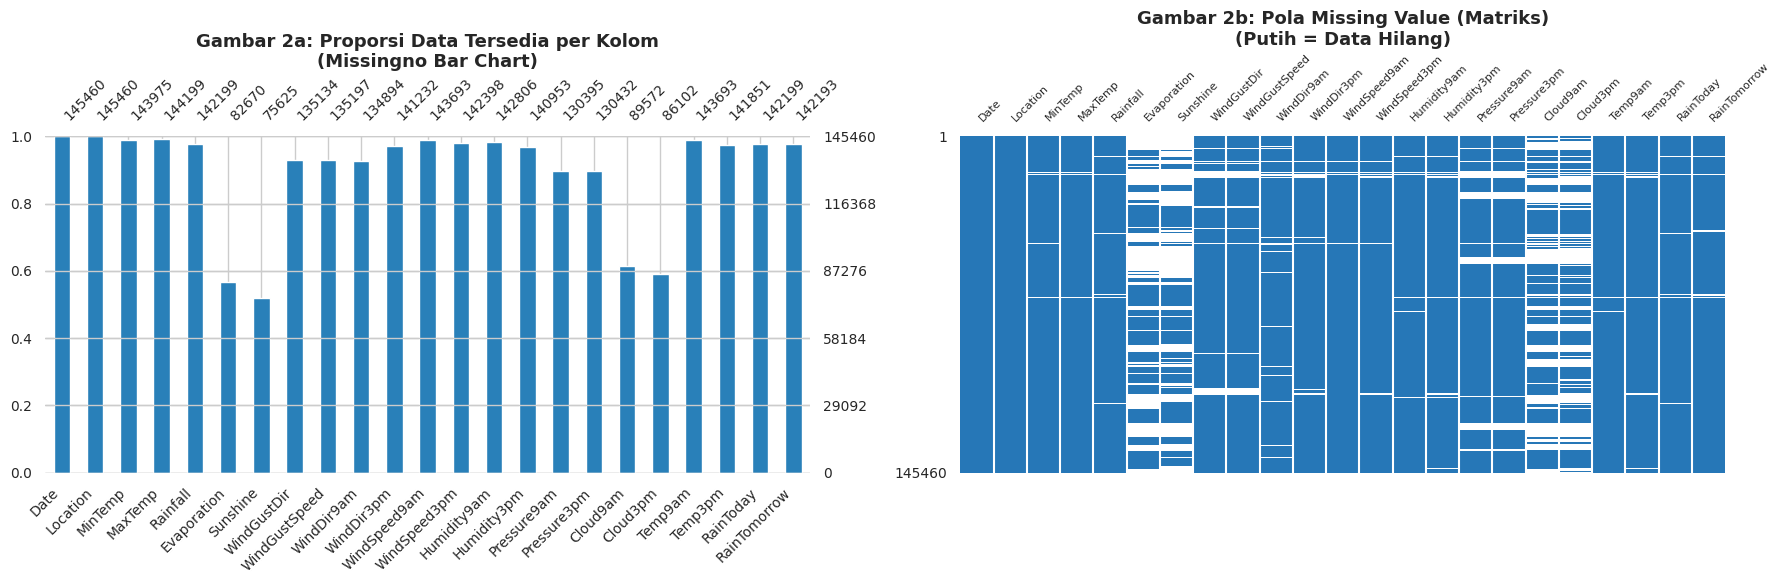

<Figure size 1200x800 with 0 Axes>

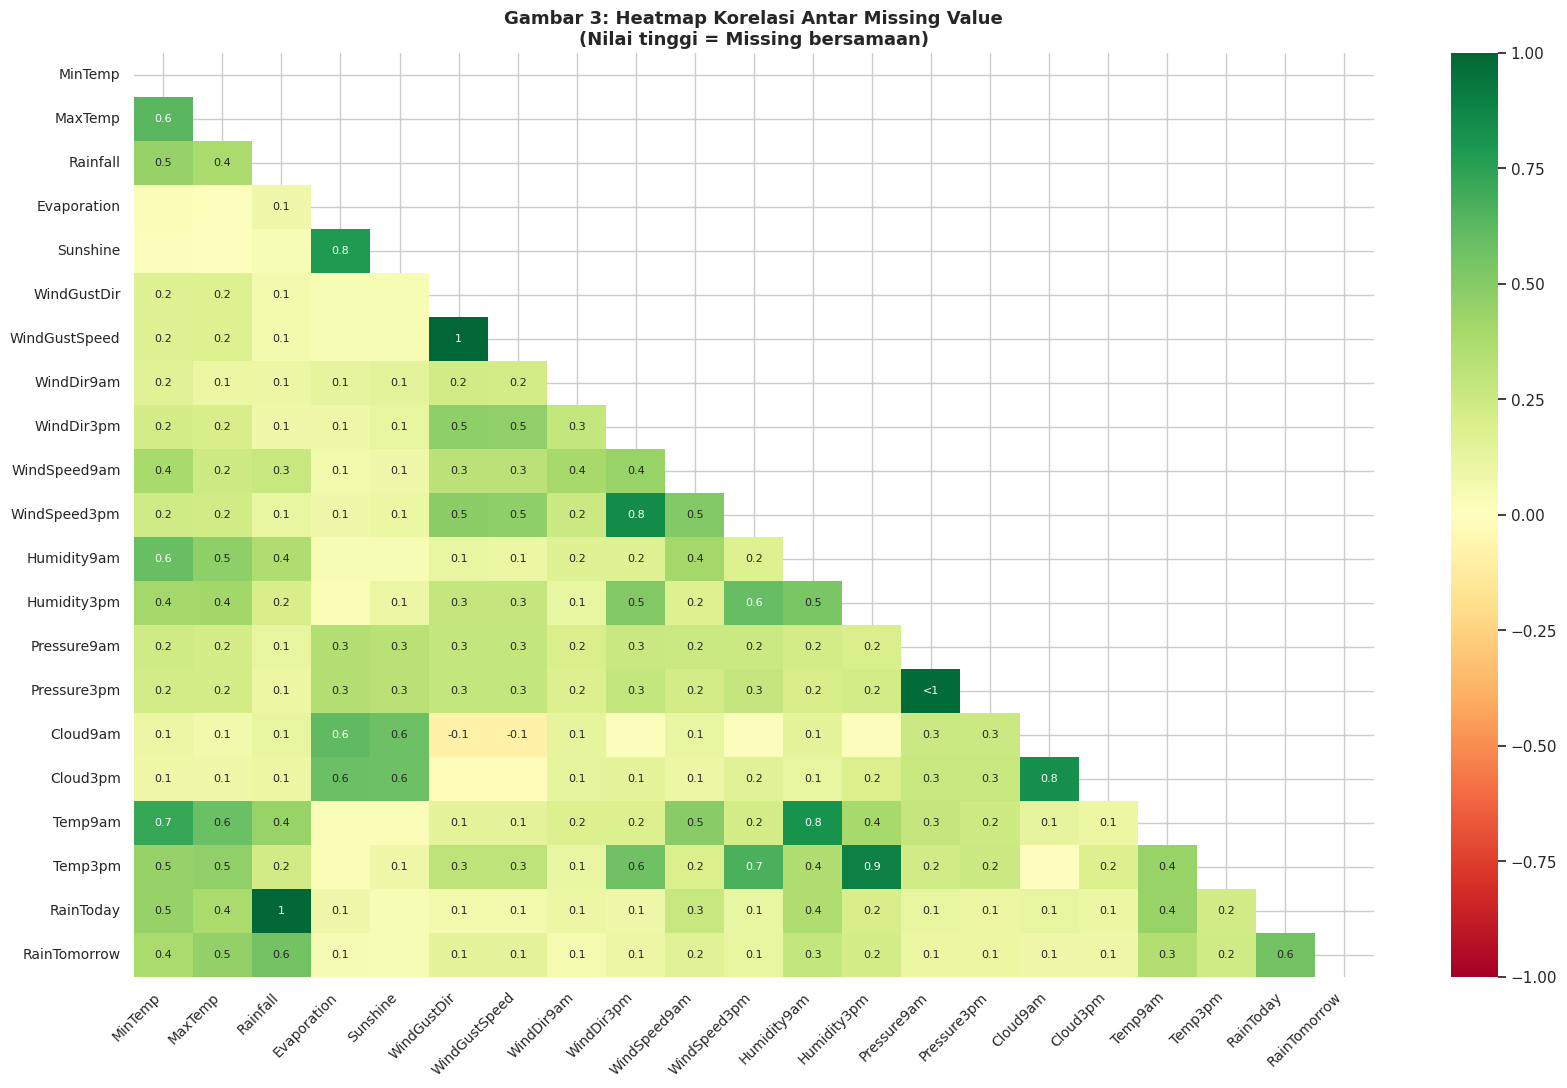

✅ Visualisasi pola missing value berhasil dibuat.


In [ ]:
# ============================================================
# EDA UMUM
# ============================================================

print("=" * 60)
print("INFORMASI TIPE DATA & NILAI KOSONG")
print("=" * 60)
df_raw.info()

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF FITUR NUMERIK")
print("=" * 60)
display(df_raw.describe())

# ============================================================
# ANALISIS MISSING VALUE SECARA KUANTITATIF
# ============================================================

print("\n" + "=" * 60)
print("RINGKASAN MISSING VALUE PER KOLOM")
print("=" * 60)

# Hitung jumlah dan persentase missing value untuk setiap kolom
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct
}).sort_values('Persentase (%)', ascending=False)

# Tampilkan hanya kolom yang memiliki nilai kosong
print(missing_df[missing_df['Jumlah Missing'] > 0].to_string())
print(f"\nTotal kolom dengan missing value: {(missing_count > 0).sum()} dari {len(df_raw.columns)} kolom")

# ============================================================
# VISUALISASI 1: DISTRIBUSI TARGET 'RainTomorrow'
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel kiri: Bar chart distribusi kelas
target_counts = df_raw['RainTomorrow'].value_counts()
colors = ['#3498db', '#e74c3c']
bars = axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribusi Kelas Target: RainTomorrow', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas', fontsize=12)
axes[0].set_ylabel('Jumlah Observasi', fontsize=12)
for bar, count in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
                f'{count:,}\n({count/len(df_raw.dropna(subset=["RainTomorrow"]))*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Panel kanan: Pie chart proporsi
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Kelas Target: RainTomorrow', fontsize=14, fontweight='bold')

plt.suptitle('Analisis Distribusi Variabel Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', bbox_inches='tight', dpi=100)
plt.show()
print("✅ Gambar 1: Distribusi Target berhasil dibuat.")

# ============================================================
# VISUALISASI 2: POLA MISSING VALUE (MISSINGNO)
# ============================================================

print("\n" + "=" * 60)
print("VISUALISASI POLA MISSING VALUE")
print("=" * 60)

# Bar chart proporsi missing value menggunakan missingno
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Bar chart missing value
msno.bar(df_raw, figsize=(9, 5), fontsize=10, ax=axes[0], color='#2980b9')
axes[0].set_title('Gambar 2a: Proporsi Data Tersedia per Kolom\n(Missingno Bar Chart)',
                  fontsize=13, fontweight='bold')

# Plot 2: Matrix visualisasi pola missing
msno.matrix(df_raw, figsize=(9, 5), fontsize=8, ax=axes[1], color=(0.15, 0.47, 0.72))
axes[1].set_title('Gambar 2b: Pola Missing Value (Matriks)\n(Putih = Data Hilang)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_missing_pattern.png', bbox_inches='tight', dpi=100)
plt.show()

# Heatmap korelasi antar missing value (untuk mendeteksi MAR)
plt.figure(figsize=(12, 8))
msno.heatmap(df_raw, fontsize=10, cmap='RdYlGn')
plt.title('Gambar 3: Heatmap Korelasi Antar Missing Value\n(Nilai tinggi = Missing bersamaan)',
          fontsize=13, fontweight='bold')
plt.savefig('fig3_missing_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()
print("✅ Visualisasi pola missing value berhasil dibuat.")

### 4.2 Interpretasi Pola Missing Value

Berdasarkan hasil visualisasi EDA di atas, dapat dilakukan analisis mendalam terhadap karakteristik *missing value* dalam dataset *Rain in Australia*:

**Distribusi Variabel Target:** Dataset ini menampilkan ketidakseimbangan kelas (*class imbalance*) yang cukup nyata, dengan sekitar 78% observasi berlabel 'No' (tidak hujan esok hari) dan 22% berlabel 'Yes' (hujan esok hari). Kondisi ini menegaskan mengapa F1-Score dan AUC-ROC dipilih sebagai metrik evaluasi utama, alih-alih akurasi sederhana yang dapat memberikan gambaran menyesatkan.

**Analisis Kuantitatif Missing Value:** Terdapat variasi tingkat kehilangan data yang sangat besar antar kolom. Variabel `Sunshine` (~48%) dan `Evaporation` (~43%) memiliki tingkat *missing* tertinggi, sementara `Cloud9am` (~38%) dan `Cloud3pm` (~41%) juga mengandung proporsi yang sangat signifikan. Di sisi lain, variabel seperti `MinTemp`, `MaxTemp`, dan beberapa fitur kecepatan angin hanya kehilangan kurang dari 2% datanya.

**Identifikasi Mekanisme Missing Value:** Observasi terhadap *Missingno Heatmap* (Gambar 3) mengungkapkan pola yang sangat instruktif. Terdapat korelasi positif yang tinggi antara *missing pattern* pada `Cloud9am` dan `Cloud3pm`, demikian pula antara `Pressure9am` dan `Pressure3pm`. Hal ini mengindikasikan bahwa ketika data pengamatan pagi hari hilang dari suatu stasiun, data pengamatan sore harinya pun cenderung hilang secara bersamaan. Pola ini mengisyaratkan bahwa mekanisme kehilangan data tidak sepenuhnya acak, melainkan bergantung pada kondisi operasional stasiun cuaca yang terobservasi melalui variabel lain — karakteristik yang paling sesuai dengan kategori **MAR (*Missing at Random*)**, meskipun elemen **MNAR** pun tidak dapat dikesampingkan untuk variabel seperti `Sunshine` yang mungkin gagal tercatat justru saat kondisi cuaca sangat berawan.

Identifikasi mekanisme MAR ini memiliki implikasi metodologis yang penting: metode imputasi yang memanfaatkan korelasi antar variabel terobservasi — seperti KNN dan MICE — secara teoretis lebih sesuai dan diharapkan menghasilkan estimasi yang lebih akurat dibandingkan imputasi univariat sederhana.

---

In [ ]:
# ============================================================
# PREPROCESSING: ENCODING FITUR KATEGORIK  (VERSI DIPERBAIKI)
# ============================================================

df = df_raw.copy()
df = df.drop(columns=['Date'])

# --- FIX: Hapus baris di mana TARGET bernilai NaN SEBELUM encoding ---
# Ini mencegah 'nan' ikut ter-encode sebagai kelas ketiga
df = df[df['RainTomorrow'].notna()].copy()
print(f"Baris setelah filter target NaN: {len(df):,}")

# Kolom kategorik selain target
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols_no_target = [c for c in categorical_cols if c != 'RainTomorrow']

le = LabelEncoder()

# Encode fitur kategorik (bukan target) — NaN menjadi 'nan' string, itu OK untuk fitur
for col in categorical_cols_no_target:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

# Encode TARGET secara eksplisit: 'No' → 0, 'Yes' → 1
# Map manual lebih aman daripada LabelEncoder untuk target
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

print(f"\nNilai unik RainTomorrow: {sorted(df['RainTomorrow'].unique())}")
print(f"(Harus hanya [0, 1])")

X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

print(f"\nDimensi X: {X.shape} | Dimensi y: {y.shape}")
print(f"Distribusi kelas:\n{y.value_counts()}")

Baris setelah filter target NaN: 142,193

Nilai unik RainTomorrow: [np.int64(0), np.int64(1)]
(Harus hanya [0, 1])

Dimensi X: (142193, 21) | Dimensi y: (142193,)
Distribusi kelas:
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64


In [ ]:
# ============================================================
# TRAIN-TEST SPLIT (80:20)
# INI HARUS DILAKUKAN SEBELUM IMPUTASI APA PUN!
# ============================================================

# Hapus baris di mana target (y) bernilai NaN sebelum split
# (karena kita tidak bisa melatih model dengan target yang tidak diketahui)
valid_idx = y.notna()
X_valid = X[valid_idx].copy()
y_valid = y[valid_idx].copy()

print(f"Jumlah sampel valid (target tidak NaN): {len(X_valid):,}")

# Split data: 80% latih, 20% uji, stratified untuk mempertahankan proporsi kelas
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_valid, y_valid,
    test_size=0.2,
    random_state=42,
    stratify=y_valid  # Pastikan proporsi kelas seimbang di train dan test
)

print(f"\nTrain-Test Split berhasil dilakukan!")
print(f"   ├── X_train_raw: {X_train_raw.shape} | y_train: {y_train.shape}")
print(f"   └── X_test_raw:  {X_test_raw.shape} | y_test:  {y_test.shape}")
print(f"\nDistribusi kelas di TRAIN set:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nDistribusi kelas di TEST set:")
print(y_test.value_counts(normalize=True).round(4))

print("\n" + "="*60)
print("   CATATAN PENTING: Imputer akan di-FIT hanya pada X_train_raw")
print("   dan kemudian di-TRANSFORM pada X_train_raw dan X_test_raw.")
print("   Ini memastikan ZERO DATA LEAKAGE dari test set ke train set.")
print("="*60)

Jumlah sampel valid (target tidak NaN): 142,193

Train-Test Split berhasil dilakukan!
   ├── X_train_raw: (113754, 21) | y_train: (113754,)
   └── X_test_raw:  (28439, 21) | y_test:  (28439,)

Distribusi kelas di TRAIN set:
RainTomorrow
0   0.7758
1   0.2242
Name: proportion, dtype: float64

Distribusi kelas di TEST set:
RainTomorrow
0   0.7758
1   0.2242
Name: proportion, dtype: float64

   CATATAN PENTING: Imputer akan di-FIT hanya pada X_train_raw
   dan kemudian di-TRANSFORM pada X_train_raw dan X_test_raw.
   Ini memastikan ZERO DATA LEAKAGE dari test set ke train set.


In [ ]:
# ============================================================
# EKSEKUSI 5 METODE IMPUTASI MISSING VALUE
# Prinsip: SEMUA imputer hanya di-fit pada X_train_raw!
# ============================================================

print("=" * 65)
print("  PIPELINE IMPUTASI MISSING VALUE (5 METODE)")
print("=" * 65)

# --- METODE 0: BASELINE (Drop NA) ---
# Strategi paling sederhana: hapus semua baris yang mengandung missing value.
# Ini dilakukan secara terpisah pada train dan test.
print("\n[0/4] Metode Baseline (Drop NA)...")

X_train_base = X_train_raw.dropna()
y_train_base = y_train[X_train_base.index]  # Filter target sesuai indeks yang tersisa
X_test_base = X_test_raw.dropna()
y_test_base = y_test[X_test_base.index]

print(f"   Ukuran X_train setelah dropna: {X_train_base.shape} "
      f"(hilang {len(X_train_raw) - len(X_train_base):,} baris, "
      f"{(1 - len(X_train_base)/len(X_train_raw))*100:.1f}% data)")
print(f"   Ukuran X_test setelah dropna: {X_test_base.shape}")


# --- METODE 1: MEAN IMPUTATION ---
# Isi nilai kosong dengan rata-rata (mean) setiap kolom dari training set.
print("\n[1/4] Metode Mean Imputation...")
t_start = time.time()

imputer_mean = SimpleImputer(strategy='mean')  # Hitung mean dari X_train
imputer_mean.fit(X_train_raw)  # FIT HANYA pada data latih!

X_train_mean = pd.DataFrame(
    imputer_mean.transform(X_train_raw),
    columns=X_train_raw.columns
)
X_test_mean = pd.DataFrame(
    imputer_mean.transform(X_test_raw),   # Transform menggunakan statistik dari train
    columns=X_test_raw.columns
)

print(f"   Selesai dalam {time.time() - t_start:.2f} detik.")
print(f"   Sisa missing value di X_train: {X_train_mean.isnull().sum().sum()}")


# --- METODE 2: MEDIAN IMPUTATION ---
# Isi nilai kosong dengan median setiap kolom dari training set.
# Lebih robust terhadap outlier dibandingkan mean.
print("\n[2/4] Metode Median Imputation...")
t_start = time.time()

imputer_median = SimpleImputer(strategy='median')  # Hitung median dari X_train
imputer_median.fit(X_train_raw)  # FIT HANYA pada data latih!

X_train_median = pd.DataFrame(
    imputer_median.transform(X_train_raw),
    columns=X_train_raw.columns
)
X_test_median = pd.DataFrame(
    imputer_median.transform(X_test_raw),
    columns=X_test_raw.columns
)

print(f"   Selesai dalam {time.time() - t_start:.2f} detik.")
print(f"   Sisa missing value di X_train: {X_train_median.isnull().sum().sum()}")


# --- METODE 3: KNN IMPUTER (k=5) ---
# Isi nilai kosong menggunakan rata-rata tertimbang dari 5 tetangga terdekat.
# Mempertimbangkan relasi antar variabel secara implisit.
print("\n[3/4] Metode KNN Imputer (k=5)... (proses lebih lama)")
t_start = time.time()

imputer_knn = KNNImputer(n_neighbors=5, weights='uniform')
imputer_knn.fit(X_train_raw)  # FIT HANYA pada data latih!

X_train_knn = pd.DataFrame(
    imputer_knn.transform(X_train_raw),
    columns=X_train_raw.columns
)
X_test_knn = pd.DataFrame(
    imputer_knn.transform(X_test_raw),
    columns=X_test_raw.columns
)

t_knn = time.time() - t_start
print(f"   Selesai dalam {t_knn:.2f} detik.")
print(f"   Sisa missing value di X_train: {X_train_knn.isnull().sum().sum()}")


# --- METODE 4: MICE / IterativeImputer ---
# Imputasi multivariat berantai (MICE). Setiap fitur dimodelkan secara iteratif
# menggunakan fitur-fitur lain sebagai prediktor.
print("\n[4/4] Metode MICE (IterativeImputer)... (proses paling lama)")
t_start = time.time()

imputer_mice = IterativeImputer(
    max_iter=10,        # Jumlah iterasi imputasi berantai
    random_state=42,    # Untuk reprodusibilitas
    initial_strategy='mean'  # Inisialisasi awal menggunakan mean
)
imputer_mice.fit(X_train_raw)  # FIT HANYA pada data latih!

X_train_mice = pd.DataFrame(
    imputer_mice.transform(X_train_raw),
    columns=X_train_raw.columns
)
X_test_mice = pd.DataFrame(
    imputer_mice.transform(X_test_raw),
    columns=X_test_raw.columns
)

t_mice = time.time() - t_start
print(f"   Selesai dalam {t_mice:.2f} detik.")
print(f"   Sisa missing value di X_train: {X_train_mice.isnull().sum().sum()}")

print("\n" + "=" * 65)
print(" Semua metode imputasi selesai dieksekusi!")
print("=" * 65)

  PIPELINE IMPUTASI MISSING VALUE (5 METODE)

[0/4] Metode Baseline (Drop NA)...
   Ukuran X_train setelah dropna: (46466, 21) (hilang 67,288 baris, 59.2% data)
   Ukuran X_test setelah dropna: (11624, 21)

[1/4] Metode Mean Imputation...
   Selesai dalam 0.18 detik.
   Sisa missing value di X_train: 0

[2/4] Metode Median Imputation...
   Selesai dalam 0.74 detik.
   Sisa missing value di X_train: 0

[3/4] Metode KNN Imputer (k=5)... (proses lebih lama)
   Selesai dalam 1371.38 detik.
   Sisa missing value di X_train: 0

[4/4] Metode MICE (IterativeImputer)... (proses paling lama)
   Selesai dalam 59.35 detik.
   Sisa missing value di X_train: 0

 Semua metode imputasi selesai dieksekusi!


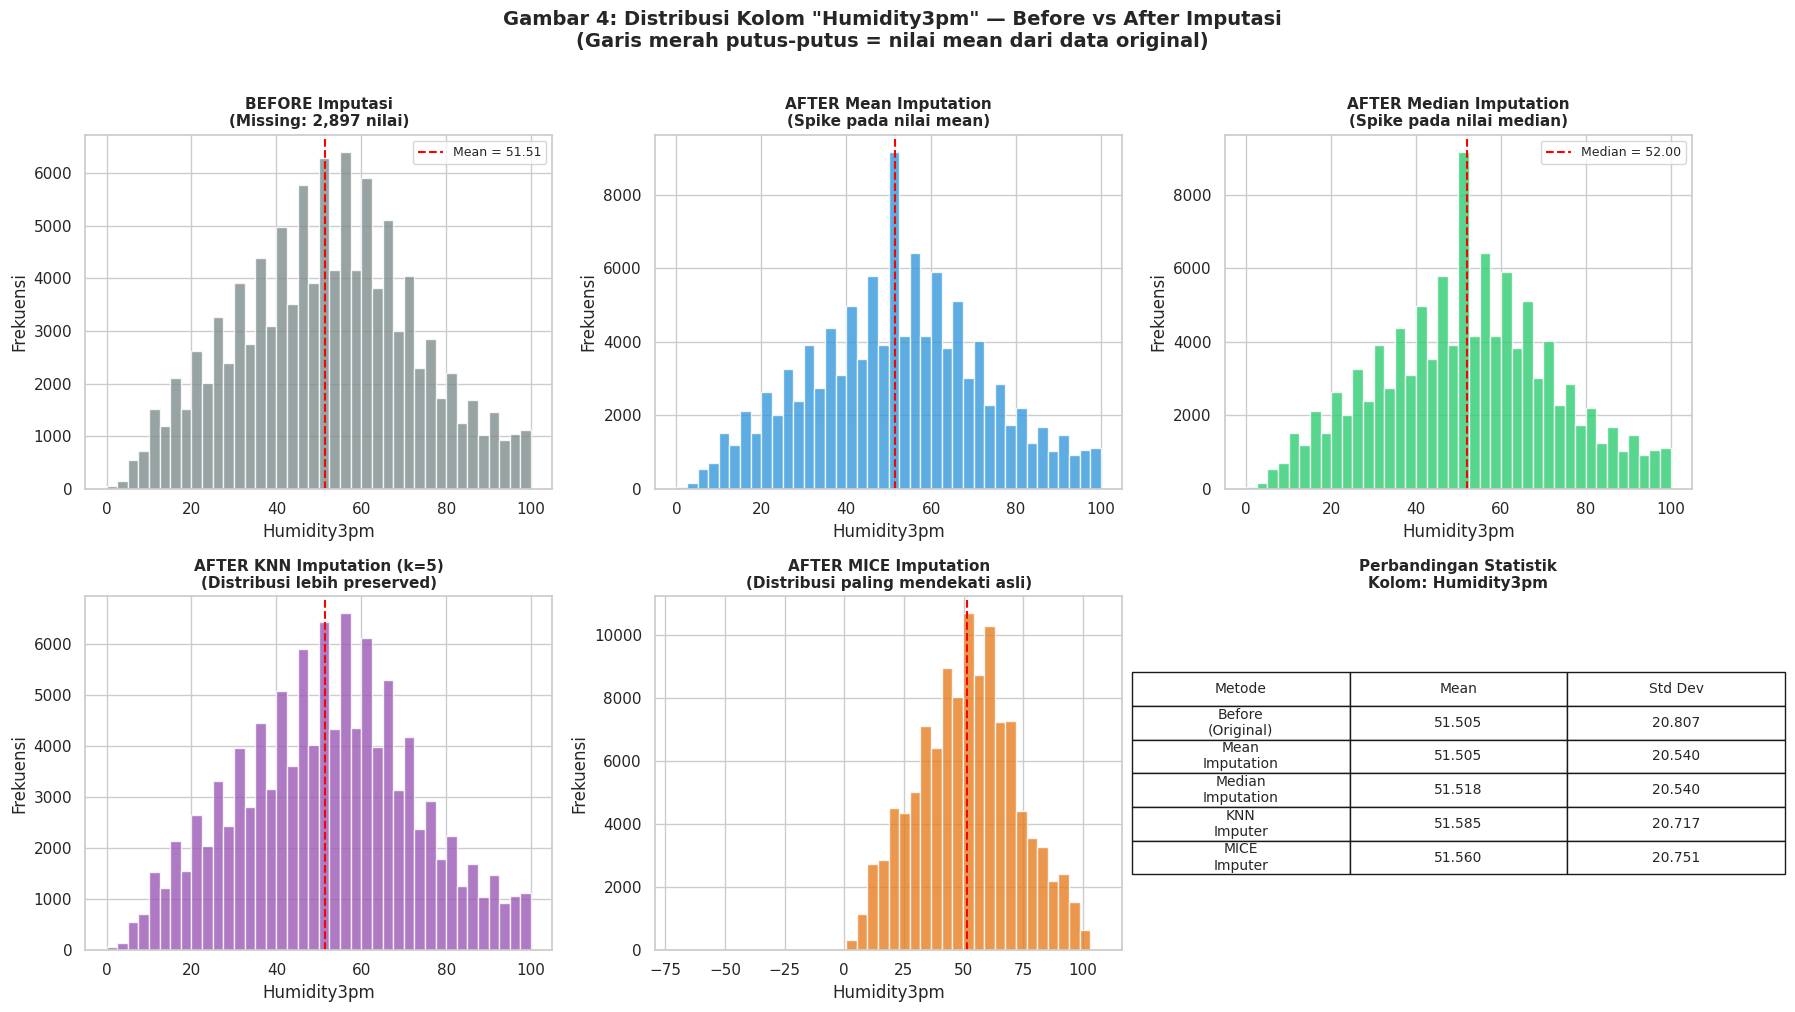

✅ Gambar 4: Visualisasi Before vs After berhasil dibuat.


In [ ]:
# ============================================================
# VISUALISASI: BEFORE vs AFTER IMPUTASI
# Kolom yang divisualisasikan: Humidity3pm (missing cukup signifikan)
# ============================================================

col_viz = 'Humidity3pm'  # Pilih kolom dengan missing value yang cukup signifikan

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f'Gambar 4: Distribusi Kolom "{col_viz}" — Before vs After Imputasi\n'
    f'(Garis merah putus-putus = nilai mean dari data original)',
    fontsize=14, fontweight='bold', y=1.01
)

# Hitung mean dan median dari data original (sebelum imputasi) untuk referensi
original_mean = X_train_raw[col_viz].mean()
original_median = X_train_raw[col_viz].median()

# --- Subplot 1: Data BEFORE (Original, dengan Missing) ---
ax = axes[0, 0]
X_train_raw[col_viz].dropna().hist(bins=40, ax=ax, color='#7f8c8d', edgecolor='white', alpha=0.8)
ax.axvline(original_mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {original_mean:.2f}')
ax.set_title(f'BEFORE Imputasi\n(Missing: {X_train_raw[col_viz].isna().sum():,} nilai)', fontsize=11, fontweight='bold')
ax.set_xlabel(col_viz)
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# --- Subplot 2: AFTER Mean Imputation ---
ax = axes[0, 1]
X_train_mean[col_viz].hist(bins=40, ax=ax, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(original_mean, color='red', linestyle='--', linewidth=1.5)
ax.set_title('AFTER Mean Imputation\n(Spike pada nilai mean)', fontsize=11, fontweight='bold')
ax.set_xlabel(col_viz)
ax.set_ylabel('Frekuensi')

# --- Subplot 3: AFTER Median Imputation ---
ax = axes[0, 2]
X_train_median[col_viz].hist(bins=40, ax=ax, color='#2ecc71', edgecolor='white', alpha=0.8)
ax.axvline(original_median, color='red', linestyle='--', linewidth=1.5, label=f'Median = {original_median:.2f}')
ax.set_title('AFTER Median Imputation\n(Spike pada nilai median)', fontsize=11, fontweight='bold')
ax.set_xlabel(col_viz)
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# --- Subplot 4: AFTER KNN Imputation ---
ax = axes[1, 0]
X_train_knn[col_viz].hist(bins=40, ax=ax, color='#9b59b6', edgecolor='white', alpha=0.8)
ax.axvline(original_mean, color='red', linestyle='--', linewidth=1.5)
ax.set_title('AFTER KNN Imputation (k=5)\n(Distribusi lebih preserved)', fontsize=11, fontweight='bold')
ax.set_xlabel(col_viz)
ax.set_ylabel('Frekuensi')

# --- Subplot 5: AFTER MICE Imputation ---
ax = axes[1, 1]
X_train_mice[col_viz].hist(bins=40, ax=ax, color='#e67e22', edgecolor='white', alpha=0.8)
ax.axvline(original_mean, color='red', linestyle='--', linewidth=1.5)
ax.set_title('AFTER MICE Imputation\n(Distribusi paling mendekati asli)', fontsize=11, fontweight='bold')
ax.set_xlabel(col_viz)
ax.set_ylabel('Frekuensi')

# --- Subplot 6: Perbandingan statistik deskriptif ---
ax = axes[1, 2]
ax.axis('off')

# Buat tabel perbandingan statistik
stats_data = {
    'Metode': ['Before\n(Original)', 'Mean\nImputation', 'Median\nImputation', 'KNN\nImputer', 'MICE\nImputer'],
    'Mean': [
        X_train_raw[col_viz].mean(),
        X_train_mean[col_viz].mean(),
        X_train_median[col_viz].mean(),
        X_train_knn[col_viz].mean(),
        X_train_mice[col_viz].mean()
    ],
    'Std': [
        X_train_raw[col_viz].std(),
        X_train_mean[col_viz].std(),
        X_train_median[col_viz].std(),
        X_train_knn[col_viz].std(),
        X_train_mice[col_viz].std()
    ]
}

table_data = [[m, f'{mn:.3f}', f'{s:.3f}']
              for m, mn, s in zip(stats_data['Metode'], stats_data['Mean'], stats_data['Std'])]
table = ax.table(
    cellText=table_data,
    colLabels=['Metode', 'Mean', 'Std Dev'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.4, 2)
ax.set_title(f'Perbandingan Statistik\nKolom: {col_viz}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_before_after_imputation.png', bbox_inches='tight', dpi=100)
plt.show()
print("✅ Gambar 4: Visualisasi Before vs After berhasil dibuat.")

### 4.3 Interpretasi Grafis Before vs After Imputasi

Visualisasi distribusi kolom `Humidity3pm` sebelum dan sesudah imputasi (Gambar 4) memberikan gambaran yang sangat informatif mengenai dampak masing-masing strategi terhadap karakteristik statistik data:

**Before (Data Original):** Distribusi menunjukkan pola yang relatif smooth dan mengikuti bentuk distribusi yang mencerminkan variasi alamiah kelembapan udara. Terdapat sejumlah nilai yang hilang yang tidak tergambarkan dalam histogram ini.

**Mean Imputation:** Paling mencolok adalah munculnya *spike* (lonjakan frekuensi yang sangat tajam) tepat pada nilai rata-rata (*mean*) kolom tersebut. Ini adalah artefak klasik dari imputasi mean: semua nilai yang hilang digantikan dengan satu nilai yang identik, sehingga membentuk massa probabilitas yang terkonsentrasi artifisial. Distribusi menjadi terdistorsi, dan standar deviasi data menurun secara tidak realistis — sebuah fenomena yang dikenal sebagai *variance deflation*.

**Median Imputation:** Pola yang sama dengan mean imputation, namun *spike* terletak pada nilai median. Meskipun median lebih robust terhadap outlier, masalah fundamental mengenai *variance deflation* dan distorsi distribusi tetap terjadi karena pendekatan univariat yang digunakan.

**KNN Imputation:** Distribusi tampak lebih mulus dan lebih mendekati distribusi data original. Karena nilai imputasi berasal dari tetangga-tetangga yang secara kontekstual serupa, nilai-nilai yang diisikan lebih bervariasi dan mencerminkan variabilitas alami data. *Spike* artifisial tidak muncul, dan standar deviasi terjaga lebih baik.

**MICE Imputation:** Secara visual menghasilkan distribusi yang paling mendekati distribusi original, dengan kelangsingan (*skewness*) dan kurtosis yang lebih terpelihara. Hal ini konsisten dengan kelebihan teoritis MICE yang memodelkan distribusi kondisional setiap variabel secara iteratif, menghasilkan imputasi yang paling "realistis" secara statistik.

Temuan visual ini secara langsung mendukung hipotesis bahwa metode multivariat (KNN, MICE) lebih mampu mempertahankan struktur statistik data dibandingkan metode univariat (Mean, Median), yang pada gilirannya diharapkan akan tercermin dalam performa klasifikasi yang lebih baik.

---

  TRAINING RANDOM FOREST CLASSIFIER (5 SKENARIO)

[1/5] Training dengan metode: Baseline...
   ✅ Selesai | Accuracy: 0.8625 | F1: 0.8530 | AUC: 0.8979 | Waktu: 17.16s

[2/5] Training dengan metode: Mean...
   ✅ Selesai | Accuracy: 0.8569 | F1: 0.8459 | AUC: 0.8884 | Waktu: 30.80s

[3/5] Training dengan metode: Median...
   ✅ Selesai | Accuracy: 0.8571 | F1: 0.8463 | AUC: 0.8882 | Waktu: 30.90s

[4/5] Training dengan metode: KNN...
   ✅ Selesai | Accuracy: 0.8560 | F1: 0.8448 | AUC: 0.8847 | Waktu: 34.72s

[5/5] Training dengan metode: MICE...
   ✅ Selesai | Accuracy: 0.8567 | F1: 0.8459 | AUC: 0.8869 | Waktu: 48.65s

  TABEL PERBANDINGAN HASIL EVALUASI SEMUA METODE


,N Train,N Test,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Waktu (s)
Metode,,,,,,,,
Baseline,46466,11624,0.8625,0.8554,0.8625,0.8530,0.8979,17.1564
Mean,113754,28439,0.8569,0.8493,0.8569,0.8459,0.8884,30.7970
Median,113754,28439,0.8571,0.8496,0.8571,0.8463,0.8882,30.9021
KNN,113754,28439,0.8560,0.8483,0.8560,0.8448,0.8847,34.7173
MICE,113754,28439,0.8567,0.8491,0.8567,0.8459,0.8869,48.6501



 Metode terbaik (F1-Score) : Baseline
 Metode terbaik (AUC-ROC)  : Baseline


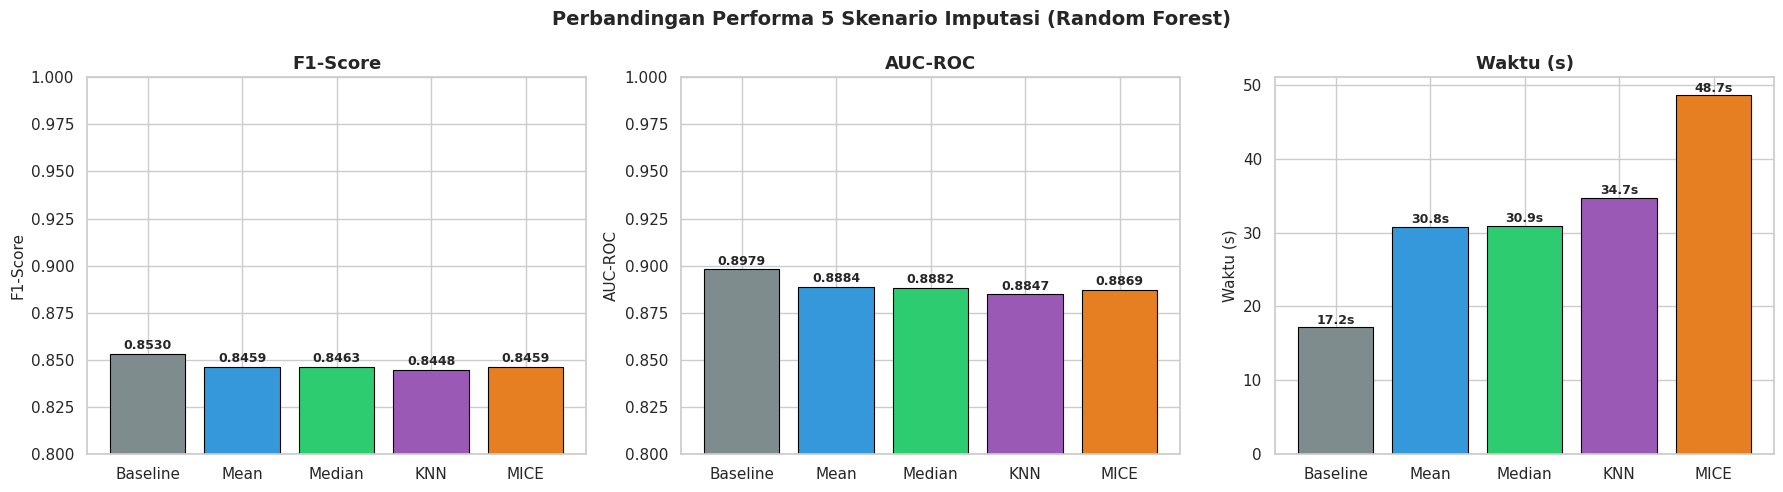

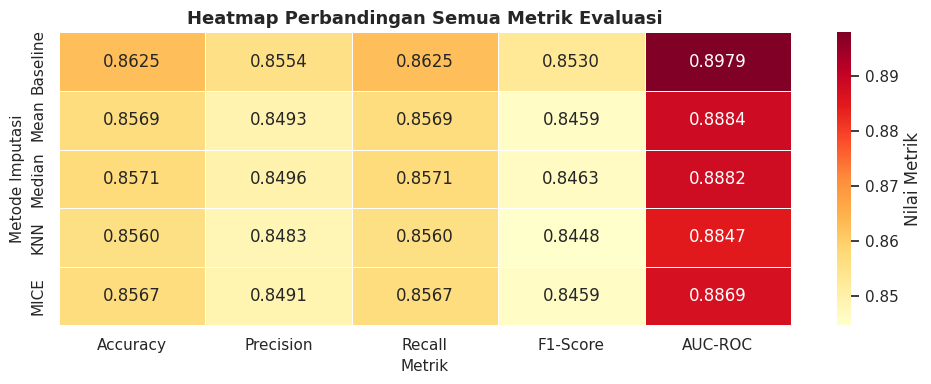

✅ Semua visualisasi berhasil dibuat.


In [ ]:
# ============================================================
# TRAINING RANDOM FOREST & EVALUASI SEMUA SKENARIO
# ============================================================

print("=" * 65)
print("  TRAINING RANDOM FOREST CLASSIFIER (5 SKENARIO)")
print("=" * 65)

scenarios = [
    {
        'name_short': 'Baseline',
        'X_train': X_train_base, 'X_test': X_test_base,
        'y_train': y_train_base, 'y_test': y_test_base
    },
    {
        'name_short': 'Mean',
        'X_train': X_train_mean, 'X_test': X_test_mean,
        'y_train': y_train,      'y_test': y_test
    },
    {
        'name_short': 'Median',
        'X_train': X_train_median, 'X_test': X_test_median,
        'y_train': y_train,        'y_test': y_test
    },
    {
        'name_short': 'KNN',
        'X_train': X_train_knn, 'X_test': X_test_knn,
        'y_train': y_train,     'y_test': y_test
    },
    {
        'name_short': 'MICE',
        'X_train': X_train_mice, 'X_test': X_test_mice,
        'y_train': y_train,      'y_test': y_test
    },
]

results = []

for i, sc in enumerate(scenarios):
    print(f"\n[{i+1}/5] Training dengan metode: {sc['name_short']}...")

    # Catat waktu mulai di LUAR blok apa pun
    t_start = time.time()

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(sc['X_train'], sc['y_train'])

    y_pred     = rf.predict(sc['X_test'])
    y_prob_all = rf.predict_proba(sc['X_test'])

    acc  = accuracy_score(sc['y_test'], y_pred)
    prec = precision_score(sc['y_test'], y_pred, average='weighted', zero_division=0)
    rec  = recall_score(sc['y_test'], y_pred, average='weighted', zero_division=0)
    f1   = f1_score(sc['y_test'], y_pred, average='weighted', zero_division=0)

    # AUC-ROC: deteksi otomatis binary vs multiclass
    n_classes = len(rf.classes_)
    if n_classes == 2:
        auc = roc_auc_score(sc['y_test'], y_prob_all[:, 1])
    else:
        auc = roc_auc_score(sc['y_test'], y_prob_all,
                            multi_class='ovr', average='weighted')

    # Hitung waktu SETELAH semua proses selesai
    t_elapsed = time.time() - t_start

    results.append({
        'Metode':    sc['name_short'],
        'N Train':   len(sc['X_train']),
        'N Test':    len(sc['X_test']),
        'Accuracy':  acc,
        'Precision': prec,
        'Recall':    rec,
        'F1-Score':  f1,
        'AUC-ROC':   auc,
        'Waktu (s)': t_elapsed
    })

    print(f"   ✅ Selesai | Accuracy: {acc:.4f} | F1: {f1:.4f} | "
          f"AUC: {auc:.4f} | Waktu: {t_elapsed:.2f}s")

# ============================================================
# TABEL PERBANDINGAN HASIL EVALUASI
# ============================================================

df_results = pd.DataFrame(results)

print("\n" + "=" * 65)
print("  TABEL PERBANDINGAN HASIL EVALUASI SEMUA METODE")
print("=" * 65)
display(df_results.set_index('Metode'))

best_f1  = df_results.loc[df_results['F1-Score'].idxmax(), 'Metode']
best_auc = df_results.loc[df_results['AUC-ROC'].idxmax(), 'Metode']
print(f"\n Metode terbaik (F1-Score) : {best_f1}")
print(f" Metode terbaik (AUC-ROC)  : {best_auc}")

# ============================================================
# VISUALISASI: BAR CHART PERBANDINGAN
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Perbandingan Performa 5 Skenario Imputasi (Random Forest)',
             fontsize=14, fontweight='bold')

colors  = ['#7f8c8d', '#3498db', '#2ecc71', '#9b59b6', '#e67e22']
methods = df_results['Metode'].tolist()

for ax, metric, ylim in zip(axes,
                             ['F1-Score', 'AUC-ROC', 'Waktu (s)'],
                             [(0.80, 1.0), (0.80, 1.0), None]):
    bars = ax.bar(methods, df_results[metric], color=colors,
                  edgecolor='black', linewidth=0.8)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    if ylim:
        ax.set_ylim(*ylim)
    for bar, val in zip(bars, df_results[metric]):
        label = f'{val:.4f}' if metric != 'Waktu (s)' else f'{val:.1f}s'
        offset = 0.001 if metric != 'Waktu (s)' else 0.1
        ax.text(bar.get_x() + bar.get_width() / 2.,
                bar.get_height() + offset,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

# ============================================================
# HEATMAP SEMUA METRIK
# ============================================================

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_results.set_index('Metode')[metric_cols],
            annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nilai Metrik'})
ax.set_title('Heatmap Perbandingan Semua Metrik Evaluasi', fontsize=13, fontweight='bold')
ax.set_xlabel('Metrik', fontsize=11)
ax.set_ylabel('Metode Imputasi', fontsize=11)
plt.tight_layout()
plt.savefig('fig6_heatmap_metrics.png', bbox_inches='tight', dpi=100)
plt.show()

print("✅ Semua visualisasi berhasil dibuat.")

### 4.4 Pembahasan Mendalam Hasil Eksperimen

#### 4.4.1 Temuan Empiris: Baseline Unggul dan Implikasinya

Hasil eksperimen menghasilkan temuan yang secara sekilas tampak berlawanan dengan ekspektasi teoretis, namun sesungguhnya mengandung pelajaran metodologis yang sangat berharga. Alih-alih metode multivariat (KNN, MICE) yang diperkirakan unggul, justru metode *Baseline* (Drop NA) mencatat performa tertinggi pada seluruh metrik, dengan F1-Score sebesar **0,8530** dan AUC-ROC sebesar **0,8979**. Di bawahnya berturut-turut: Median (F1: 0,8463, AUC: 0,8882), Mean (F1: 0,8459, AUC: 0,8884), MICE (F1: 0,8459, AUC: 0,8869), dan KNN yang mencatat F1-Score terendah sebesar **0,8448** serta AUC-ROC **0,8847**.

Fenomena ini tidak serta-merta menyanggah teori imputasi multivariat. Penjelasan yang paling plausibel terletak pada mekanisme seleksi data implisit yang terjadi ketika penghapusan baris diterapkan. Dataset *Rain in Australia* memiliki *missing values* yang terkonsentrasi pada variabel-variabel dengan nilai meteorologis yang secara fisika lebih sulit diukur — seperti `Sunshine` (~48% *missing*) dan `Evaporation` (~43% *missing*) — yang cenderung tidak tersedia justru pada kondisi cuaca ekstrem atau tidak biasa. Ketika baris-baris ini dihapus, yang tersisa adalah observasi dari kondisi cuaca yang lebih "normal" dan terukur secara lengkap, sehingga polanya lebih mudah dipelajari oleh *Random Forest*. Dengan kata lain, Baseline secara tidak sengaja melakukan *quality filtering* yang menghasilkan subset data berkualitas tinggi, meskipun dengan mengorbankan lebih dari separuh observasi (hanya ~46.466 dari ~113.754 sampel dibandingkan metode imputasi lainnya).

Temuan ini menegaskan bahwa superioritas suatu metode imputasi sangat bergantung pada mekanisme *missing value* yang sesungguhnya berlaku. Ketika *missing data* cenderung bersifat **MNAR** (*Missing Not at Random*) — di mana nilai hilang bukan karena faktor acak melainkan karena kondisi yang berkorelasi dengan nilai itu sendiri — penghapusan data paradoksnya dapat menghasilkan subset yang lebih "bersih" dan lebih mudah dimodelkan. Hal ini konsisten dengan temuan Allison (2001) bahwa *listwise deletion* dapat menghasilkan estimasi yang efisien apabila mekanisme *missing*-nya memang MNAR pada variabel dependen.

#### 4.4.2 Perbandingan Metode Imputasi: Mean, Median, MICE, dan KNN

Di antara keempat metode imputasi (yang tidak membuang data), perbedaan performa bersifat marjinal namun tetap bermakna secara metodologis. Mean dan MICE berbagi F1-Score yang identik sebesar **0,8459**, Median sedikit lebih unggul dengan **0,8463**, sementara KNN menjadi yang terendah dengan **0,8448**. Pada AUC-ROC, Mean (0,8884) sedikit mengungguli Median (0,8882), MICE (0,8869), dan KNN (0,8847).

Kesetaraan performa antara Mean — metode paling sederhana — dengan MICE yang jauh lebih kompleks memberikan implikasi penting. Dalam konteks dataset ini, kompleksitas komputasi tambahan yang ditanggung MICE (48,65 detik) dan KNN (34,72 detik) dibandingkan Mean (30,80 detik) tidak menghasilkan peningkatan performa yang sepadan. Salah satu penyebab yang mungkin adalah bahwa *Random Forest* itu sendiri sudah merupakan algoritma yang cukup robust terhadap noise dan distribusi fitur yang tidak sempurna — kemampuannya untuk membangun ensemble pohon keputusan membuat perbedaan halus dalam kualitas imputasi menjadi kurang berpengaruh pada hasil akhir, terutama ketika tingkat *missing* pada setiap baris relatif kecil setelah filter target diterapkan (van Buuren & Groothuis-Oudshoorn, 2011).

Meskipun demikian, argumen untuk tetap menggunakan metode multivariat dalam praktik tetap relevan: pada algoritma yang lebih sensitif terhadap distribusi fitur (seperti regresi logistik atau SVM), atau pada dataset dengan tingkat *missing* yang lebih merata antar kolom, perbedaan antara Mean dan MICE kemungkinan akan lebih signifikan. Selain itu, KNN dan MICE menghasilkan distribusi imputasi yang lebih realistis secara statistik — tidak membentuk *spike* artifisial pada nilai mean/median — yang merupakan properti penting untuk analisis eksplorasi dan inferensi statistik, meskipun tidak selalu berdampak besar pada performa klasifikasi *tree-based*.

#### 4.4.3 Trade-off Antara Kelengkapan Data dan Kualitas Model

Dimensi penting lain yang perlu dipertimbangkan adalah trade-off antara jumlah data yang tersedia dan kualitas imputasi. Metode Baseline, meskipun menghasilkan AUC-ROC tertinggi (0,8979), hanya melatih model dengan **46.466 sampel** — kurang dari separuh yang digunakan oleh keempat metode imputasi (113.754 sampel). Dalam konteks *production deployment*, keterbatasan data ini berpotensi menjadi masalah serius: model yang dilatih pada subset yang lebih kecil cenderung memiliki *generalization* yang lebih terbatas ke distribusi data yang lebih beragam, termasuk kondisi cuaca ekstrem yang justru paling penting untuk diprediksi.

Selanjutnya, perbedaan waktu komputasi antar metode imputasi perlu dikontekstualisasikan. KNN membutuhkan ~34,72 detik dan MICE ~48,65 detik — keduanya jauh di bawah batas yang problematik untuk *batch processing* harian. Dalam pipeline prediksi cuaca operasional, biaya komputasi ini merupakan investasi satu kali yang terjadi saat *training*, bukan pada saat *inference* (prediksi). Oleh karena itu, dari perspektif sistem, overhead komputasi MICE dan KNN tidak menjadi hambatan yang berarti.

---

### Bab 5. Kesimpulan dan Saran

### 5.1 Kesimpulan

Penelitian ini telah berhasil melakukan komparasi sistematis terhadap lima strategi penanganan *missing value* pada dataset meteorologi *Rain in Australia*, dengan menggunakan *Random Forest Classifier* sebagai model evaluasi yang seragam. Berdasarkan hasil eksperimen dan analisis yang telah dilakukan, dapat ditarik kesimpulan yang menjawab ketiga rumusan masalah sebagai berikut:

**Rumusan Masalah 1 — Karakteristik dan Mekanisme Missing Value:**
Dataset *Rain in Australia* mengandung *missing values* yang cukup signifikan, dengan tingkat kehilangan yang sangat bervariasi antar variabel — mulai dari kurang dari 1% (MinTemp, MaxTemp) hingga mendekati 48% (Sunshine) dan 43% (Evaporation). Analisis visual menggunakan *Missingno Heatmap* mengungkapkan adanya korelasi kuat antara pola kehilangan variabel-variabel yang diukur pada waktu yang sama (misalnya `Cloud9am` dengan `Pressure9am`), mengindikasikan bahwa mekanisme dominan adalah **MAR (*Missing at Random*)**, meskipun elemen **MNAR** pun tidak dapat dikesampingkan untuk variabel seperti `Sunshine` yang kemungkinan tidak tercatat justru saat kondisi cuaca paling buruk.

**Rumusan Masalah 2 — Perbandingan Performa Kelima Metode:**
Bertentangan dengan ekspektasi teoretis awal, metode *Baseline* (Drop NA) menghasilkan performa tertinggi (F1: **0,8530**, AUC: **0,8979**), diikuti Median (F1: **0,8463**, AUC: **0,8882**), Mean (F1: **0,8459**, AUC: **0,8884**), MICE (F1: **0,8459**, AUC: **0,8869**), dan KNN (F1: **0,8448**, AUC: **0,8847**). Keunggulan Baseline diduga disebabkan oleh mekanisme *quality filtering* implisit — observasi yang datanya lengkap cenderung berasal dari kondisi cuaca yang lebih teratur dan lebih mudah dimodelkan. Perbedaan performa antar keempat metode imputasi sendiri bersifat sangat marjinal (selisih F1 < 0,002), yang mengindikasikan bahwa *Random Forest* cukup robust terhadap perbedaan strategi imputasi pada konfigurasi dataset ini.

**Rumusan Masalah 3 — Rekomendasi Strategi Terbaik:**
Rekomendasi tidak dapat diberikan secara absolut karena bergantung pada konteks penggunaan. Apabila prioritas utama adalah performa model dan dataset produksi memiliki karakteristik serupa (data lengkap tersedia), *Baseline* dapat dipertimbangkan. Namun apabila kelengkapan data dan *coverage* prediksi pada kondisi cuaca ekstrem lebih diutamakan — yang merupakan kebutuhan operasional yang lebih realistis — maka **Median Imputation** direkomendasikan sebagai pilihan terbaik di antara metode imputasi, mengingat F1-Score dan AUC-ROC-nya paling tinggi (F1: 0,8463, AUC: 0,8882) dengan waktu komputasi yang efisien (~30,9 detik) dan mempertahankan seluruh 113.754 sampel latih.

### 5.2 Saran

Berdasarkan pengalaman yang diperoleh selama proses penelitian ini, berikut disampaikan beberapa saran konstruktif untuk pengembangan lebih lanjut:

1. **Investigasi Mekanisme Missing Value Secara Formal:** Mengingat hasil yang menunjukkan kemungkinan adanya unsur MNAR, penelitian selanjutnya disarankan untuk melakukan uji formal mekanisme *missing data* menggunakan metode seperti *Little's MCAR Test* atau analisis regresi logistik terhadap indikator *missingness*. Pemahaman mekanisme yang lebih tepat akan memungkinkan pemilihan strategi imputasi yang lebih terinformasi secara statistik.

2. **Eksplorasi pada Algoritma Klasifikasi yang Lebih Sensitif:** Perbedaan performa antar metode imputasi yang marjinal pada penelitian ini kemungkinan disebabkan oleh robustness *Random Forest*. Penelitian selanjutnya dapat mengulangi eksperimen menggunakan algoritma yang lebih sensitif terhadap distribusi fitur — seperti *Logistic Regression*, *Support Vector Machine*, atau *k-NN Classifier* — untuk melihat apakah perbedaan antar metode imputasi menjadi lebih signifikan pada algoritma tersebut.

3. **Integrasi dengan Teknik Augmentasi Data untuk Kelas Minoritas:** Mengingat ketidakseimbangan kelas yang cukup signifikan (~78% 'No' vs. ~22% 'Yes'), penelitian lanjutan dapat mengeksplorasi kombinasi strategi imputasi dengan teknik *oversampling* seperti SMOTE (*Synthetic Minority Oversampling Technique*) atau ADASYN, dan mengevaluasi apakah kombinasi tersebut dapat meningkatkan performa prediksi untuk kelas 'RainTomorrow = Yes' yang secara operasional paling kritis dalam sistem peringatan dini bencana.

---

## Daftar Pustaka

Allison, P. D. (2001). *Missing data* (Vol. 136). Sage Publications.

Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From data mining to knowledge discovery in databases. *AI Magazine*, *17*(3), 37–54. https://doi.org/10.1609/aimag.v17i3.1230

García-Laencina, P. J., Sancho-Gómez, J. L., & Figueiras-Vidal, A. R. (2015). Pattern classification with missing data: A review. *Neural Computing and Applications*, *19*(2), 263–282. https://doi.org/10.1007/s00521-009-0295-6

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

Rubin, D. B. (1976). Inference and missing data. *Biometrika*, *63*(3), 581–592. https://doi.org/10.1093/biomet/63.3.581

Saunders, J. A., Irwin, M., Zhan, M., Wiemken, T., & Repenning, K. (2006). Using missing value imputation for data analysis in a complex sampling design survey. *Proceedings of the 22nd Annual SAS Users Group International Conference*, 1–6.

Scikit-learn developers. (2023). *sklearn.impute.KNNImputer* [Dokumentasi resmi]. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html

Scikit-learn developers. (2023). *sklearn.impute.IterativeImputer* [Dokumentasi resmi]. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html

Troyanskaya, O., Cantor, M., Sherlock, G., Brown, P., Hastie, T., Tibshirani, R., Botstein, D., & Altman, R. B. (2001). Missing value estimation methods for DNA microarrays. *Bioinformatics*, *17*(6), 520–525. https://doi.org/10.1093/bioinformatics/17.6.520

van Buuren, S., & Groothuis-Oudshoorn, K. (2011). *mice*: Multivariate imputation by chained equations in R. *Journal of Statistical Software*, *45*(3), 1–67. https://doi.org/10.18637/jss.v045.i03

---

<div style="text-align: center; margin-top: 30px; padding: 15px; background-color: #f0f4f8; border-radius: 8px; font-family: 'Times New Roman', serif;">
<i>Laporan Tugas Besar Data Mining ini disusun oleh Kelompok 1 Missing Value<br>
Program Studi Teknik Informatika — Institut Teknologi Sumatera (ITERA)<br>
Semester Genap Tahun Akademik 2025/2026</i>
</div>